In [ ]:
# Paths in this notebook are relative to the repository root; move there when opened from analysis/.
import os
from pathlib import Path
if not Path('Experiments_constraints').is_dir() and (Path('..') / 'Experiments_constraints').is_dir():
    os.chdir('..')
print('CWD:', os.getcwd())

# Cumulative Regret for `Experiments_constraint_continuous`

This notebook mirrors the cumulative regret calculation used in `analyze.ipynb`:

- load each saved `*.pth` training file
- repeat each `true_response` value by its saved `queries` count
- compute instantaneous regret as `abs(F_OPT - true_response)`
- plot the mean cumulative regret with standard error bands across all discovered runs

By default `F_OPT = 0.0`, matching the MAE objective convention used in `analyze.ipynb`.

In [1]:
from collections import defaultdict
from pathlib import Path
import os
import re

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-quan-fuselage")

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path("Experiments_constraint_continuous_actuators_4")

# Match analyze.ipynb: cumulative regret = cumsum(abs(F_OPT - true_response)).
# If you have a better known optimum for a new run, change it here.
F_OPT = 0.0

# None uses every discovered step. Set this to an integer for faster/shorter plots.
MAX_BUDGET = 50_000
PLOT_X_LIM = MAX_BUDGET

# Manually choose which experiment sets to show.
# Examples: [0], [1], [0, 1, 2], list(range(10)), or None for every exp_set found.
EXP_SET_FILTER = [0]

# Set to None to use every trial found. Example: range(5).
TRIAL_FILTER = None

SAVE_FIGURES = False
CUMULATIVE_FIG = "constraint_continuous_cumulative_regret.png"
RUNNING_MIN_FIG = "constraint_continuous_running_minimum.png"

# Loading on CPU is usually enough for analysis and avoids occupying a GPU.
DEVICE = torch.device("cpu")

plt.rc("font", size=14)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600

print(f"Root      : {ROOT.resolve()}")
print(f"Device    : {DEVICE}")
print(f"F_OPT     : {F_OPT}")
print(f"Max budget: {MAX_BUDGET}")

Root      : /data/liuj35/quan_fuselage/Experiments_constraint_continuous_actuators_4
Device    : cpu
F_OPT     : 0.0
Max budget: 50000


In [2]:
METHOD_STYLE = {
    "Q-Safe-Set-UCB": {"color": "#625be6", "marker": "v"},
    "C-Safe-Set-UCB": {"color": "#2ca02c", "marker": "o"},
    "BO-ACL": {"color": "#9467bd", "marker": "D"},
}
METHOD_ORDER = ["Q-Safe-Set-UCB", "C-Safe-Set-UCB", "BO-ACL"]


def classify_training_file(file_path):
    """Return (method, noise, trial) for a saved training-data file."""
    name = file_path.name

    if "quan_training_data" in name:
        method = "Q-Safe-Set-UCB"
        token = "quan_training_data"
    elif "classic_safeset_training_data" in name:
        method = "C-Safe-Set-UCB"
        token = "classic_safeset_training_data"
    elif "training_data" in name and "ACL" in str(file_path.parent.parent):
        method = "BO-ACL"
        token = "training_data"
    else:
        return None

    match = re.match(rf"(?P<noise>.*?){token}_(?P<trial>\d+)_\.pth$", name)
    if match is None:
        return None

    return method, float(match.group("noise")), int(match.group("trial"))


def parse_exp_set(file_path):
    for part in file_path.parts:
        match = re.match(r"exp_set_(\d+)$", part)
        if match:
            return int(match.group(1))
    return None


def discover_runs(root=ROOT, exp_set_filter=EXP_SET_FILTER, trial_filter=TRIAL_FILTER):
    rows = []
    exp_filter = None if exp_set_filter is None else set(exp_set_filter)
    trial_filter = None if trial_filter is None else set(trial_filter)

    for file_path in sorted(root.rglob("*training_data_*_.pth")):
        if "ckpt" in file_path.name:
            continue

        parsed = classify_training_file(file_path)
        if parsed is None:
            continue

        method, noise, trial = parsed
        exp_set = parse_exp_set(file_path)

        if exp_filter is not None and exp_set not in exp_filter:
            continue
        if trial_filter is not None and trial not in trial_filter:
            continue

        rows.append({
            "method": method,
            "noise": noise,
            "sigma": float(np.sqrt(noise)),
            "exp_set": exp_set,
            "trial": trial,
            "path": file_path,
        })

    return rows


def to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    return np.asarray(value).reshape(-1)


def load_training_data(file_path, device=DEVICE):
    return torch.load(file_path, map_location=device, weights_only=False)


def expand_by_queries(values, queries):
    values = to_numpy_1d(values).astype(float)
    queries = to_numpy_1d(queries).astype(np.int64)

    if len(values) != len(queries):
        raise ValueError(f"values and queries have different lengths: {len(values)} vs {len(queries)}")

    # Zero-query rows are bookkeeping rows in some experiment files, not oracle calls.
    keep = queries > 0
    return np.repeat(values[keep], queries[keep])


def compute_cumulative_regret(true_response, queries, f_opt=F_OPT):
    expanded = expand_by_queries(true_response, queries)
    instantaneous = np.abs(float(f_opt) - expanded)
    return np.cumsum(instantaneous)


def compute_running_minimum(true_response, queries):
    expanded = expand_by_queries(true_response, queries)
    return np.minimum.accumulate(expanded)


def mean_stderr_curve(curves):
    min_len = min(len(curve) for curve in curves)
    arr = np.vstack([curve[:min_len] for curve in curves])
    mean = arr.mean(axis=0)
    stderr = arr.std(axis=0) / np.sqrt(arr.shape[0])
    return {
        "arr": arr,
        "mean": mean,
        "lb": mean - stderr,
        "ub": mean + stderr,
        "stderr": stderr,
        "min_len": min_len,
        "n_runs": arr.shape[0],
    }


def plot_mean_ci(ax, x, mean, lb, ub, color, marker, label, linestyle="-"):
    markevery = max(1, len(x) // 8)
    ax.fill_between(x, lb, ub, color=color, alpha=0.15)
    line, = ax.plot(
        x,
        mean,
        color=color,
        marker=marker,
        markevery=markevery,
        markersize=6,
        linewidth=2,
        linestyle=linestyle,
        label=label,
    )
    return line

In [3]:
runs = discover_runs()
print(f"Discovered {len(runs)} training files")

if not runs:
    raise RuntimeError(f"No training files found under {ROOT}")

groups = defaultdict(list)
for row in runs:
    groups[(row["method"], row["noise"])].append(row)

for method in METHOD_ORDER:
    for noise in sorted({key[1] for key in groups if key[0] == method}):
        rows = groups[(method, noise)]
        exp_sets = sorted({row["exp_set"] for row in rows})
        trials = sorted({row["trial"] for row in rows})
        print(
            f"{method:16s} sigma={np.sqrt(noise):.1f} "
            f"files={len(rows):2d} exp_sets={exp_sets} trials={trials}"
        )

Discovered 15 training files
Q-Safe-Set-UCB   sigma=0.1 files= 5 exp_sets=[0] trials=[0, 1, 2, 3, 4]
C-Safe-Set-UCB   sigma=0.1 files= 5 exp_sets=[0] trials=[0, 1, 2, 3, 4]
BO-ACL           sigma=0.1 files= 5 exp_sets=[0] trials=[0, 1, 2, 3, 4]


In [4]:
def collect_results(runs, max_budget=MAX_BUDGET):
    grouped = defaultdict(list)
    for row in runs:
        grouped[(row["method"], row["noise"])].append(row)

    results = {}
    summary_rows = []

    for (method, noise), rows in sorted(grouped.items(), key=lambda item: (item[0][0], item[0][1])):
        cumulative_curves = []
        running_min_curves = []
        best_values = []
        final_regrets = []
        loaded_rows = []

        for row in rows:
            try:
                data = load_training_data(row["path"])
                cumulative = compute_cumulative_regret(data["true_response"], data["queries"], F_OPT)
                running_min = compute_running_minimum(data["true_response"], data["queries"])

                if max_budget is not None:
                    cumulative = cumulative[:max_budget]
                    running_min = running_min[:max_budget]

                if len(cumulative) == 0:
                    print(f"[WARN] Skipping empty curve: {row['path']}")
                    continue

                cumulative_curves.append(cumulative)
                running_min_curves.append(running_min)
                best_values.append(float(to_numpy_1d(data["true_response"]).min()))
                final_regrets.append(float(cumulative[-1]))
                loaded_rows.append(row)
            except Exception as exc:
                print(f"[WARN] {row['path']}: {exc}")

        if not cumulative_curves:
            continue

        cumulative_stats = mean_stderr_curve(cumulative_curves)
        running_min_stats = mean_stderr_curve(running_min_curves)

        key = (method, noise)
        results[key] = {
            "rows": loaded_rows,
            "cumulative": cumulative_stats,
            "running_minimum": running_min_stats,
            "best_values": np.asarray(best_values),
            "final_regrets": np.asarray(final_regrets),
        }

        summary_rows.append({
            "method": method,
            "sigma": float(np.sqrt(noise)),
            "noise": noise,
            "n_runs": len(loaded_rows),
            "exp_sets": sorted({row["exp_set"] for row in loaded_rows}),
            "common_steps": cumulative_stats["min_len"],
            "final_cum_regret_mean": cumulative_stats["mean"][-1],
            "final_cum_regret_stderr": cumulative_stats["stderr"][-1],
            "best_true_response_mean": float(np.mean(best_values)),
            "best_true_response_std": float(np.std(best_values)),
        })

        print(
            f"Loaded {method:16s} sigma={np.sqrt(noise):.1f}: "
            f"runs={len(loaded_rows):2d}, common_steps={cumulative_stats['min_len']}"
        )

    return results, summary_rows


results, summary_rows = collect_results(runs)

Loaded BO-ACL           sigma=0.1: runs= 5, common_steps=50000
Loaded C-Safe-Set-UCB   sigma=0.1: runs= 5, common_steps=50000
Loaded Q-Safe-Set-UCB   sigma=0.1: runs= 5, common_steps=50000


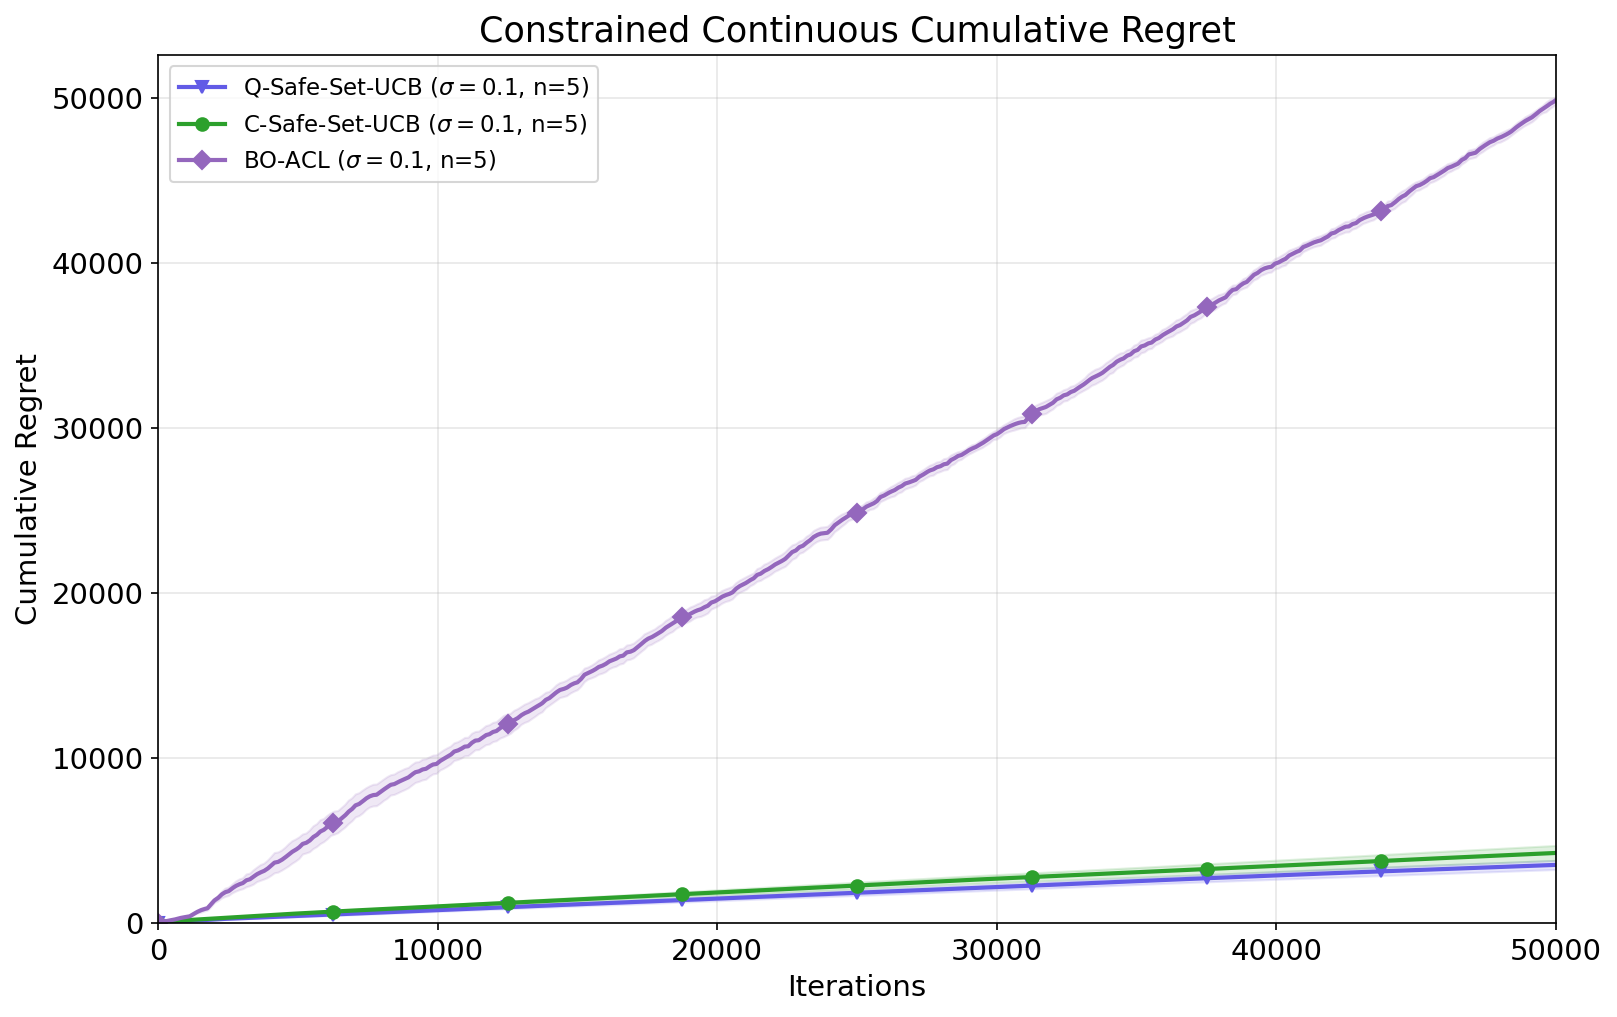

In [5]:
linestyle_by_noise = {}
for idx, noise in enumerate(sorted({noise for _, noise in results})):
    linestyle_by_noise[noise] = ["-", "--", ":", "-."][idx % 4]

fig, ax = plt.subplots(figsize=(11, 7))

for method in METHOD_ORDER:
    for noise in sorted(noise for (m, noise) in results if m == method):
        stats = results[(method, noise)]["cumulative"]
        end = stats["min_len"] if PLOT_X_LIM is None else min(stats["min_len"], PLOT_X_LIM)
        x = np.arange(1, end + 1)
        style = METHOD_STYLE[method]
        label = f"{method} ($\\sigma={np.sqrt(noise):.1f}$, n={stats['n_runs']})"
        plot_mean_ci(
            ax,
            x,
            stats["mean"][:end],
            stats["lb"][:end],
            stats["ub"][:end],
            color=style["color"],
            marker=style["marker"],
            linestyle=linestyle_by_noise[noise],
            label=label,
        )

ax.set_xlim(left=0, right=PLOT_X_LIM)
ax.set_ylim(bottom=0)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cumulative Regret")
ax.set_title("Constrained Continuous Cumulative Regret")
ax.grid(True, alpha=0.3)
ax.legend(prop={"size": 11})

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(CUMULATIVE_FIG, dpi=600, bbox_inches="tight")
    print(f"Saved {CUMULATIVE_FIG}")
plt.show()

In [6]:
try:
    import pandas as pd

    summary_df = pd.DataFrame(summary_rows).sort_values(["sigma", "method"]).reset_index(drop=True)
    display(summary_df)
except Exception:
    for row in sorted(summary_rows, key=lambda r: (r["sigma"], r["method"])):
        print(
            f"{row['method']:16s} sigma={row['sigma']:.1f} runs={row['n_runs']:2d} "
            f"steps={row['common_steps']:6d} "
            f"final={row['final_cum_regret_mean']:.3f} +- {row['final_cum_regret_stderr']:.3f} "
            f"best={row['best_true_response_mean']:.5f} +- {row['best_true_response_std']:.5f}"
        )

,method,sigma,noise,n_runs,exp_sets,common_steps,final_cum_regret_mean,final_cum_regret_stderr,best_true_response_mean,best_true_response_std
0,BO-ACL,0.1,0.01,5,[0],50000,49899.788776,251.770598,0.050302,0.013540
1,C-Safe-Set-UCB,0.1,0.01,5,[0],50000,4252.639257,454.083070,0.068859,0.018069
2,Q-Safe-Set-UCB,0.1,0.01,5,[0],50000,3528.144722,277.780745,0.058732,0.010398


## Running Minimum

This is not cumulative regret, but it is useful for checking whether high regret is caused by slow improvement or by expensive repeated queries.

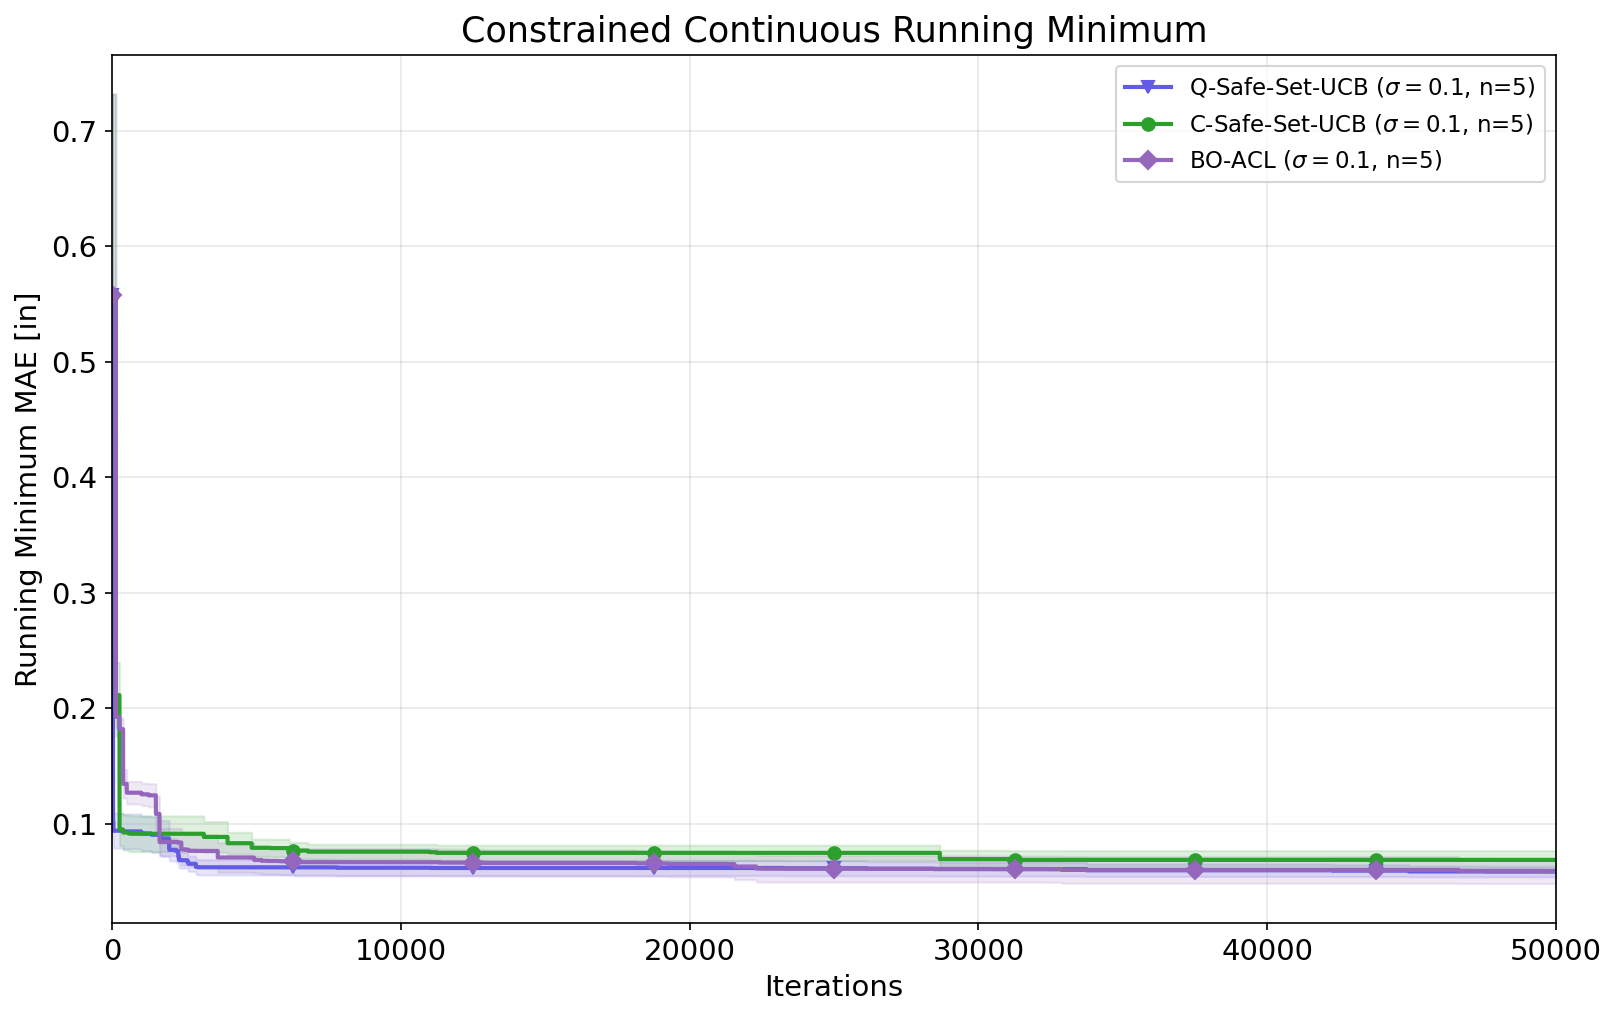

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

for method in METHOD_ORDER:
    for noise in sorted(noise for (m, noise) in results if m == method):
        stats = results[(method, noise)]["running_minimum"]
        end = stats["min_len"] if PLOT_X_LIM is None else min(stats["min_len"], PLOT_X_LIM)
        x = np.arange(1, end + 1)
        style = METHOD_STYLE[method]
        label = f"{method} ($\\sigma={np.sqrt(noise):.1f}$, n={stats['n_runs']})"
        plot_mean_ci(
            ax,
            x,
            stats["mean"][:end],
            stats["lb"][:end],
            stats["ub"][:end],
            color=style["color"],
            marker=style["marker"],
            linestyle=linestyle_by_noise[noise],
            label=label,
        )

ax.set_xlim(left=0, right=PLOT_X_LIM)
ax.set_xlabel("Iterations")
ax.set_ylabel("Running Minimum MAE [in]")
ax.set_title("Constrained Continuous Running Minimum")
ax.grid(True, alpha=0.3)
ax.legend(prop={"size": 11})

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(RUNNING_MIN_FIG, dpi=600, bbox_inches="tight")
    print(f"Saved {RUNNING_MIN_FIG}")
plt.show()

In [8]:
# ── Print Minimum Solutions Per Experiment Set ────────────────────────
# Uses the same discover_runs() + EXP_SET_FILTER as previous cells.

from collections import defaultdict

filtered_runs = discover_runs()  # respects EXP_SET_FILTER / TRIAL_FILTER

# Group by (method, noise, exp_set)
grouped = defaultdict(list)
for row in filtered_runs:
    grouped[(row['method'], row['noise'], row['exp_set'])].append(row)

for (method, noise, exp_set) in sorted(grouped.keys()):
    rows = grouped[(method, noise, exp_set)]
    print(f"{'='*70}")
    print(f" {method}  |  noise={noise}  |  exp_set_{exp_set}  ({len(rows)} trials)")
    print(f"{'='*70}")

    trial_mins = []
    for row in sorted(rows, key=lambda r: r['trial']):
        data = load_training_data(row['path'])
        tr = to_numpy_1d(data.get('true_response', data.get('Y_true')))
        resp = to_numpy_1d(data.get('response')) if data.get('response') is not None else None
        queries = to_numpy_1d(data.get('queries', data.get('stages')))

        active = queries > 0
        tr_a = tr[active]
        q_a  = queries[active]

        if len(tr_a) == 0:
            print(f"  Trial {row['trial']}: NO DATA")
            continue

        cumq = np.cumsum(q_a)
        min_idx = np.argmin(tr_a)
        min_val = tr_a[min_idx]
        q_at_min = cumq[min_idx]
        stage_q  = int(q_a[min_idx])

        # Compute |observed - true| at the min stage
        if resp is not None and len(resp) > 0:
            resp_a = resp[active]
            obs_err = abs(resp_a[min_idx] - tr_a[min_idx])
            err_str = f"{obs_err:.6f}"
        else:
            err_str = 'N/A'

        total_q = q_a.sum()
        n_stages = int(active.sum())
        mean_q = q_a.mean()

        trial_mins.append(min_val)

        print(f"  Trial {row['trial']:2d}:  min f(x)={min_val:.6f}  @cum_q={q_at_min:>6.0f}  "
              f"stage_q={stage_q:>4d}  |obs-true|={err_str}  "
              f"stages={n_stages}  mean_q/stage={mean_q:.1f}")

    if trial_mins:
        print(f"  {'─'*66}")
        print(f"  Average min f(x): {np.mean(trial_mins):.6f}  "
              f"Best: {np.min(trial_mins):.6f}  "
              f"Worst: {np.max(trial_mins):.6f}")
    print()


 BO-ACL  |  noise=0.010000000000000002  |  exp_set_0  (5 trials)
  Trial  0:  min f(x)=0.047948  @cum_q= 22428  stage_q= 126  |obs-true|=0.234403  stages=397  mean_q/stage=126.0
  Trial  1:  min f(x)=0.100541  @cum_q= 46746  stage_q= 126  |obs-true|=0.405001  stages=397  mean_q/stage=126.0
  Trial  2:  min f(x)=0.037156  @cum_q= 33012  stage_q= 126  |obs-true|=0.130848  stages=397  mean_q/stage=126.0
  Trial  3:  min f(x)=0.037342  @cum_q=  7560  stage_q= 126  |obs-true|=0.126831  stages=397  mean_q/stage=126.0
  Trial  4:  min f(x)=0.073622  @cum_q= 47754  stage_q= 126  |obs-true|=0.316875  stages=397  mean_q/stage=126.0
  ──────────────────────────────────────────────────────────────────
  Average min f(x): 0.059322  Best: 0.037156  Worst: 0.100541

 C-Safe-Set-UCB  |  noise=0.010000000000000002  |  exp_set_0  (5 trials)
  Trial  0:  min f(x)=0.079095  @cum_q= 17633  stage_q=6398  |obs-true|=0.345925  stages=16  mean_q/stage=3150.1
  Trial  1:  min f(x)=0.052002  @cum_q= 41960  stage